In [2]:
# Ejemplo ARIMA (p,d,q) con un dataset real (Sunspots) incluido en statsmodels
# Requisitos: pip install pandas numpy matplotlib statsmodels

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.datasets import sunspots
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
# -----------------------------
# 1) Cargar dataset (sunspots)
# -----------------------------
data = sunspots.load_pandas().data  # columnas: YEAR, SUNACTIVITY
data["YEAR"] = data["YEAR"].astype(int)

In [13]:
data.head(3)

,YEAR,SUNACTIVITY
0,1700,5.0
1,1701,11.0
2,1702,16.0


In [14]:
# Convertimos YEAR a un índice temporal (frecuencia anual)
y = data.set_index(pd.to_datetime(data["YEAR"], format="%Y"))["SUNACTIVITY"]
y = y.asfreq("YS")  # Year Start
y.name = "sunspots"

print("Rango de fechas:", y.index.min().date(), "->", y.index.max().date())
print("N puntos:", len(y))


Rango de fechas: 1700-01-01 -> 2008-01-01
N puntos: 309


In [15]:
# -----------------------------
# 2) (Opcional) Test de estacionariedad (ADF)
# -----------------------------
adf_stat, pvalue, *_ = adfuller(y.dropna())
print(f"ADF stat={adf_stat:.3f} | p-value={pvalue:.4f} (p<0.05 sugiere estacionaria)")

ADF stat=-2.838 | p-value=0.0531 (p<0.05 sugiere estacionaria)


In [16]:
# -----------------------------
# 3) Train / Test split
# -----------------------------
split = int(len(y) * 0.8)
train, test = y.iloc[:split], y.iloc[split:]

In [17]:
# -----------------------------
# 4) Búsqueda simple de (p,d,q) por AIC (rápida y didáctica)
#    (en la práctica podrías usar auto_arima, pero aquí lo dejamos “puro statsmodels”)
# -----------------------------
def grid_search_arima(train_series, p_range=range(0, 5), d_range=range(0, 3), q_range=range(0, 5)):
    best_aic = np.inf
    best_order = None

    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    res = model.fit()
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p, d, q)
                except Exception:
                    pass

    return best_order, best_aic

best_order, best_aic = grid_search_arima(train)
#el valor AIC se usa para puntuar modelos
#es un valor de ajuste y complejidad, a menor AIC, mejor modelo
#es necesario también obtener estas métricas: MAE/RMSE
print("Mejor (p,d,q) por AIC:", best_order, "| AIC:", round(best_aic, 2))

Mejor (p,d,q) por AIC: (4, 1, 4) | AIC: 2011.49


In [18]:
# -----------------------------
# 5) Entrenar ARIMA con el mejor (p,d,q) y predecir
# -----------------------------
model = ARIMA(train, order=best_order)
res = model.fit()

forecast = res.forecast(steps=len(test))
forecast.index = test.index  # alinear índice

# Métricas sencillas
mae = np.mean(np.abs(test - forecast))
rmse = np.sqrt(np.mean((test - forecast) ** 2))
print(f"MAE={mae:.3f} | RMSE={rmse:.3f}")

MAE=33.998 | RMSE=40.348


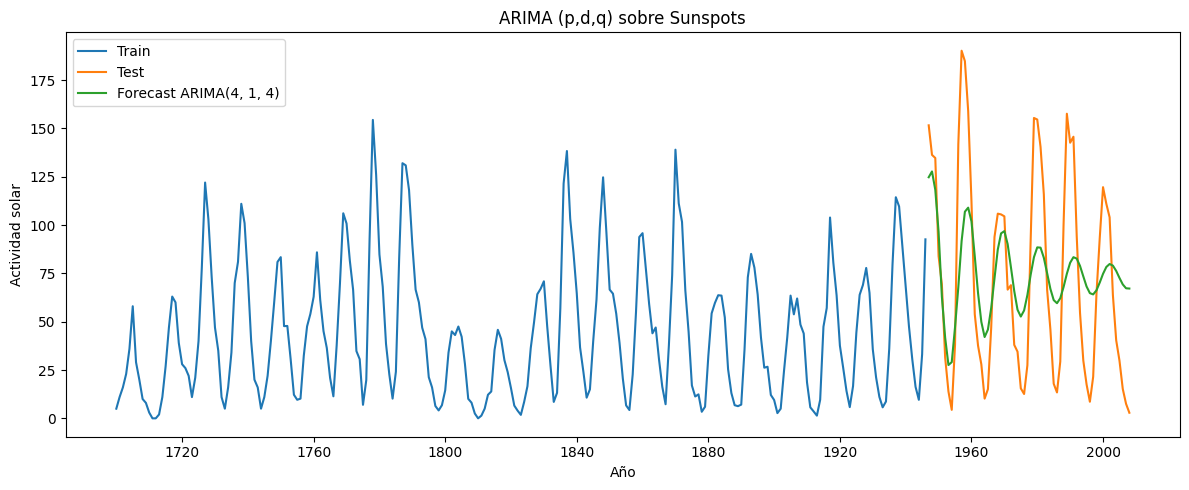

                               SARIMAX Results                                
Dep. Variable:               sunspots   No. Observations:                  247
Model:                 ARIMA(4, 1, 4)   Log Likelihood                -996.743
Date:                Wed, 07 Jan 2026   AIC                           2011.487
Time:                        17:52:40   BIC                           2043.035
Sample:                    01-01-1700   HQIC                          2024.190
                         - 01-01-1946                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2851      0.076      3.740      0.000       0.136       0.434
ar.L2          0.4220      0.057      7.344      0.000       0.309       0.535
ar.L3          0.0399      0.075      0.535      0.5

In [19]:
# -----------------------------
# 6) Visualización
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(forecast.index, forecast, label=f"Forecast ARIMA{best_order}")
plt.title("ARIMA (p,d,q) sobre Sunspots")
plt.xlabel("Año")
plt.ylabel("Actividad solar")
plt.legend()
plt.tight_layout()
plt.show()

# (Opcional) Resumen del modelo
print(res.summary())
